# Visualisierung eines Noise2Void-Runs

In diesem Notebook gibst du **einmalig** den Pfad zu deinem gespeicherten Run-Ordner an.  
Dann werden daraus automatisch geladen:
- die `config.py` (aus `used_source`),  
- dein U-Net-Modell mit dem Checkpoint `best.pt`,  
- Trainings- und Validierungs-Datasets,  
- und es werden exemplarisch je drei Beispiele aus Training und Validation geplottet.

# Parameter setzen:

In [1]:
import os
import sys

# — Stelle hier deinen Run-Ordner ein (z.B. …/trained_models/First_Test) —
run_dir = "../trained_models/fT_5Layers"  # <-- anpassen

# GPU wählen
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # or whichever GPU you want

# Andere parameter automatisch laden

In [2]:
# ── Zelle 2: Run-Config & used_source in sys.path einfügen ──

import os
import sys
import importlib.util

# 1) Absoluter Pfad zum Run-Verzeichnis (aus Zelle 1)
run_dir = os.path.abspath(run_dir)

# 2) Pfad zum used_source-Snapshot
USED_SRC = os.path.join(run_dir, "used_source")

# 3) Ganz vorne in sys.path einfügen, damit alle Imports daraus gezogen werden
if USED_SRC not in sys.path:
    sys.path.insert(0, USED_SRC)

# (Optional) Projekt-Root als Fallback auf Position 1
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(1, PROJECT_ROOT)

# Debug: sys.path prüfen
print("⤷ sys.path[0:2] =", sys.path[:2])

# 4) Pfad zur Config im used_source-Ordner
config_path = os.path.join(USED_SRC, "config.py")

# 5) Dynamisch als Modul importieren
spec = importlib.util.spec_from_file_location("run_config", config_path)
run_config = importlib.util.module_from_spec(spec)
spec.loader.exec_module(run_config)

# 6) Absoluten Pfad für checkpoint_dir anpassen (falls relativ)
if not os.path.isabs(run_config.checkpoint_dir):
    run_config.checkpoint_dir = os.path.join(PROJECT_ROOT, run_config.checkpoint_dir)

# 7) Werte ausgeben
print(f"RUN_NAME           = {run_config.RUN_NAME}")
print(f"Checkpoint-Ordner  = {run_config.checkpoint_dir}")


⤷ sys.path[0:2] = ['/workspace/Deuterium_Denosing/trained_models/fT_5Layers/used_source', '/workspace/Deuterium_Denosing']


RUN_NAME           = fT_5Layers
Checkpoint-Ordner  = /workspace/Deuterium_Denosing/trained_models/fT_5Layers/checkpoints


# Bibliotheken und Geräte

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Device auswählen
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Verwendetes Device:", device)

Verwendetes Device: cuda


# Model laden

In [4]:
from models.unet2d import UNet2D

# U-Net aus Config instantiieren
model = UNet2D(
    in_channels = run_config.in_channels,
    out_channels= run_config.out_channels,
    features    = run_config.features
).to(device)

# Checkpoint best.pt laden
ckpt = torch.load(os.path.join(run_config.checkpoint_dir, "best.pt"), map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()
print("Modell geladen von:", run_config.checkpoint_dir)


Modell geladen von: /workspace/Deuterium_Denosing/trained_models/fT_5Layers/checkpoints


In [5]:
run_config.val_data

['P08']

# Datasets & DataLoader

In [ ]:
# ── Full-Volume Inference über das gesamte Validation-Set inkl. Inverse-FFT ───

import numpy as np
import torch
from itertools import product
from data.data_utils import load_and_preprocess_data
from data.data_utils import low_rank

rank = 8

# 1) Volles Val-Set laden (roh, ohne Normierung)
dataset_dir = os.path.join(PROJECT_ROOT, "datasets")
data_val = load_and_preprocess_data(
    folder_names = run_config.val_data,
    base_path    = dataset_dir,
    fourier_axes = run_config.fourier_transform_axes,
    normalize    = True  # ORINGAL FALSE
)  # → shape: (X, Y, Z, ..., D), dtype=complex64

# 2) Array für die Denoising-Ergebnisse vorbereiten (gleicher Shape)
out_data = np.zeros_like(data_val, dtype=np.complex64)

# 3) Achsen definieren
image_axes = run_config.image_axes
all_axes   = list(range(data_val.ndim))
other_axes = [ax for ax in all_axes if ax not in image_axes]
ranges     = [range(data_val.shape[ax]) for ax in other_axes]

# 4) Loop über alle Kombinationen der non-image-Achsen
model.eval()
with torch.no_grad():
    for idx in product(*ranges):
        # a) Slicer bauen
        slicer = [ slice(None) if ax in image_axes else idx[other_axes.index(ax)]
                   for ax in all_axes ]

        # b) 2D-Spektrum extrahieren → 2-Kanal (Real+Imag)
        spec   = data_val[tuple(slicer)]
        real   = np.real(spec).astype(np.float32)
        imag   = np.imag(spec).astype(np.float32)
        img2ch = np.stack([real, imag], axis=0)  # (2, H, W)

        # c) Modell-Inferenz
        inp    = torch.from_numpy(img2ch)[None].to(device)  # (1,2,H,W)
        out_ch = model(inp).squeeze(0).cpu().numpy()         # (2, H, W)
        den    = out_ch[0] + 1j * out_ch[1]                  # (H, W)

        # d) zurückschreiben
        out_data[tuple(slicer)] = den

# 5) D-Dimension entfernen (wenn nur ein Datensatz in val_data)
out_data = out_data[..., 0]  # → (X, Y, Z, t, T)
tgt_data = data_val[..., 0]  # original noisy Spektrum

# 6) Inverse Fourier-Transformation zurück in FID-/Zeit-Domain
axes = tuple(run_config.fourier_transform_axes)
# 6a) Shift zurücksetzen
out_data = np.fft.ifftshift(out_data, axes=axes)
tgt_data = np.fft.ifftshift(tgt_data, axes=axes)
# 6b) Inverse FFT anwenden
out_data = np.fft.ifftn(out_data, axes=axes)
tgt_data = np.fft.ifftn(tgt_data, axes=axes)

#### optional extra low rank
out_data = low_rank(out_data, rank=rank)

#### OPTIONAL ONLY FOR XY_tT SWAPPED DATE

# out_data = np.transpose(out_data, (3, 4, 2, 0, 1))
# tgt_data = np.transpose(tgt_data, (3, 4, 2, 0, 1))

#### OPTIONAL ENDE!!!

baseline_data = low_rank(tgt_data, rank=rank)  # shape: (X, Y, Z, t, T)

# normalize 
out_data = out_data/np.max(np.abs(out_data))
tgt_data = tgt_data/np.max(np.abs(tgt_data))
baseline_data =  baseline_data/np.max(np.abs(baseline_data))

# 7) Fourier-Transformation entlang Achse 3 (FID → Spektrum, MIT fftshift)
out_data_ft      = np.fft.fftshift(np.fft.fft(out_data, axis=3), axes=3)
tgt_data_ft      = np.fft.fftshift(np.fft.fft(tgt_data, axis=3), axes=3)
baseline_data_ft = np.fft.fftshift(np.fft.fft(baseline_data, axis=3), axes=3)

print("Inference + inverse FFT abgeschlossen.")
print("out_data shape:", out_data.shape)
print("tgt_data shape:", tgt_data.shape)



Inference + inverse FFT abgeschlossen.
out_data shape: (22, 22, 21, 96, 8)
tgt_data shape: (22, 22, 21, 96, 8)


# Optional als matlab datei speichern

In [7]:
# from scipy.io import savemat
# savemat('P08.mat', {'Data': out_data})

# Compare FID

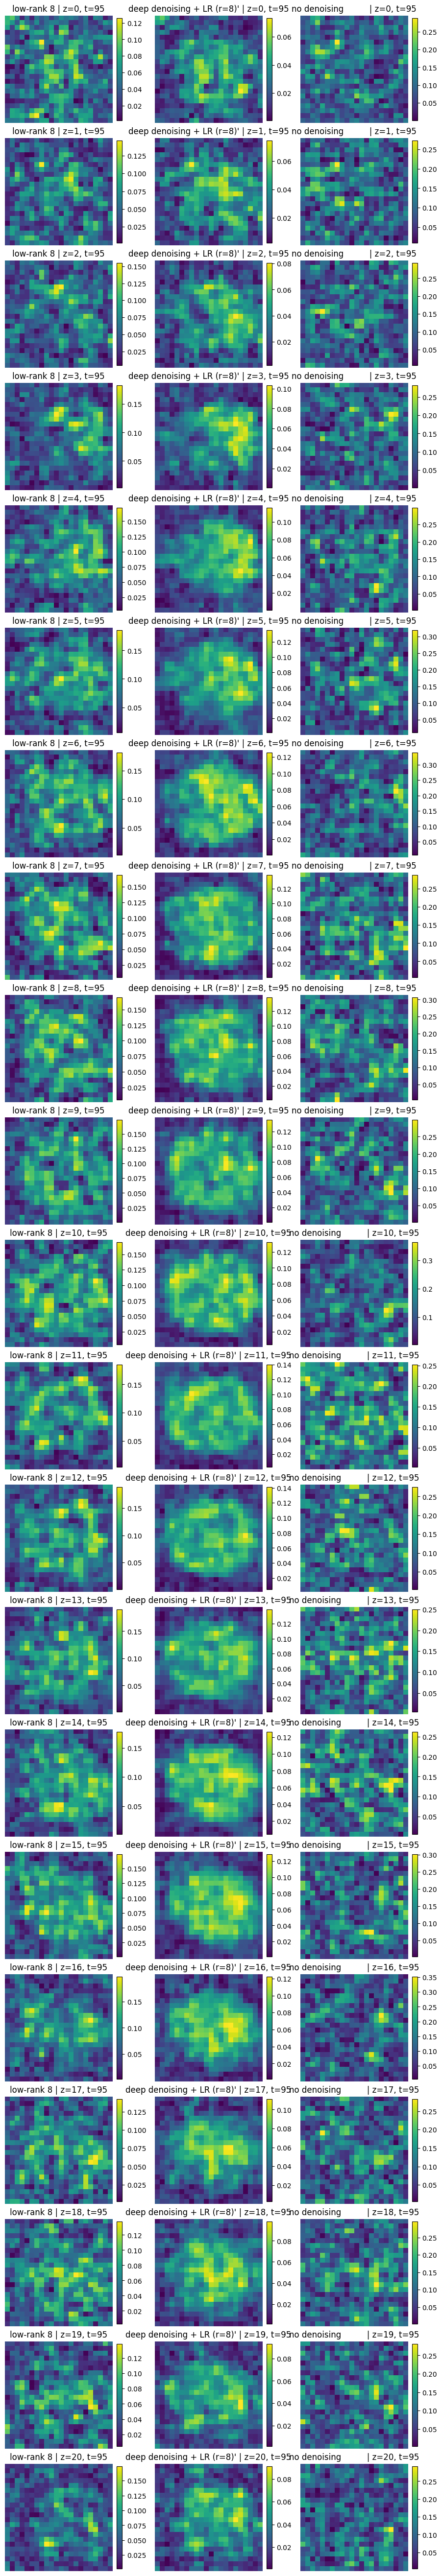

In [8]:
# ── Vergleich aller Z-Slices: Low-Rank | Deep Denoising | Input ─────────────

import numpy as np
import matplotlib.pyplot as plt

# 1) t- und T-Indizes einstellen
t, T = 95, 7

# 2) Anzahl der Z-Slices automatisch ermitteln
n_slices = out_data.shape[2]

# 3) Subplots erzeugen: n_slices Zeilen × 3 Spalten
fig, axes = plt.subplots(
    n_slices, 3,
    figsize=(9, n_slices * 2.5),
    constrained_layout=True
)

for i, z in enumerate(range(n_slices)):
    # 4) 2D-Slices extrahieren
    slice_lr   = np.abs(baseline_data[:, :, z, t, T])  # Low-Rank
    slice_deep = np.abs(out_data[:, :, z, t, T])       # Deep Denoised
    slice_in   = np.abs(tgt_data[:, :, z, t, T])       # Original Input

    # 5a) Low-Rank
    im0 = axes[i, 0].imshow(slice_lr,   cmap='viridis')
    axes[i, 0].set_title(f"low-rank {rank} | z={z}, t={t}")
    axes[i, 0].axis('off')
    plt.colorbar(im0, ax=axes[i, 0], fraction=0.046, pad=0.04)

    # 5b) Deep Denoising
    im1 = axes[i, 1].imshow(slice_deep, cmap='viridis')
    axes[i, 1].set_title(f"deep denoising + LR (r={rank})' | z={z}, t={t}")
    axes[i, 1].axis('off')
    plt.colorbar(im1, ax=axes[i, 1], fraction=0.046, pad=0.04)

    # 5c) Input
    im2 = axes[i, 2].imshow(slice_in,   cmap='viridis')
    axes[i, 2].set_title(f"no denoising          | z={z}, t={t}")
    axes[i, 2].axis('off')
    plt.colorbar(im2, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.savefig("denoising_p2n.png", dpi=300)
plt.show()

# Compare spectra

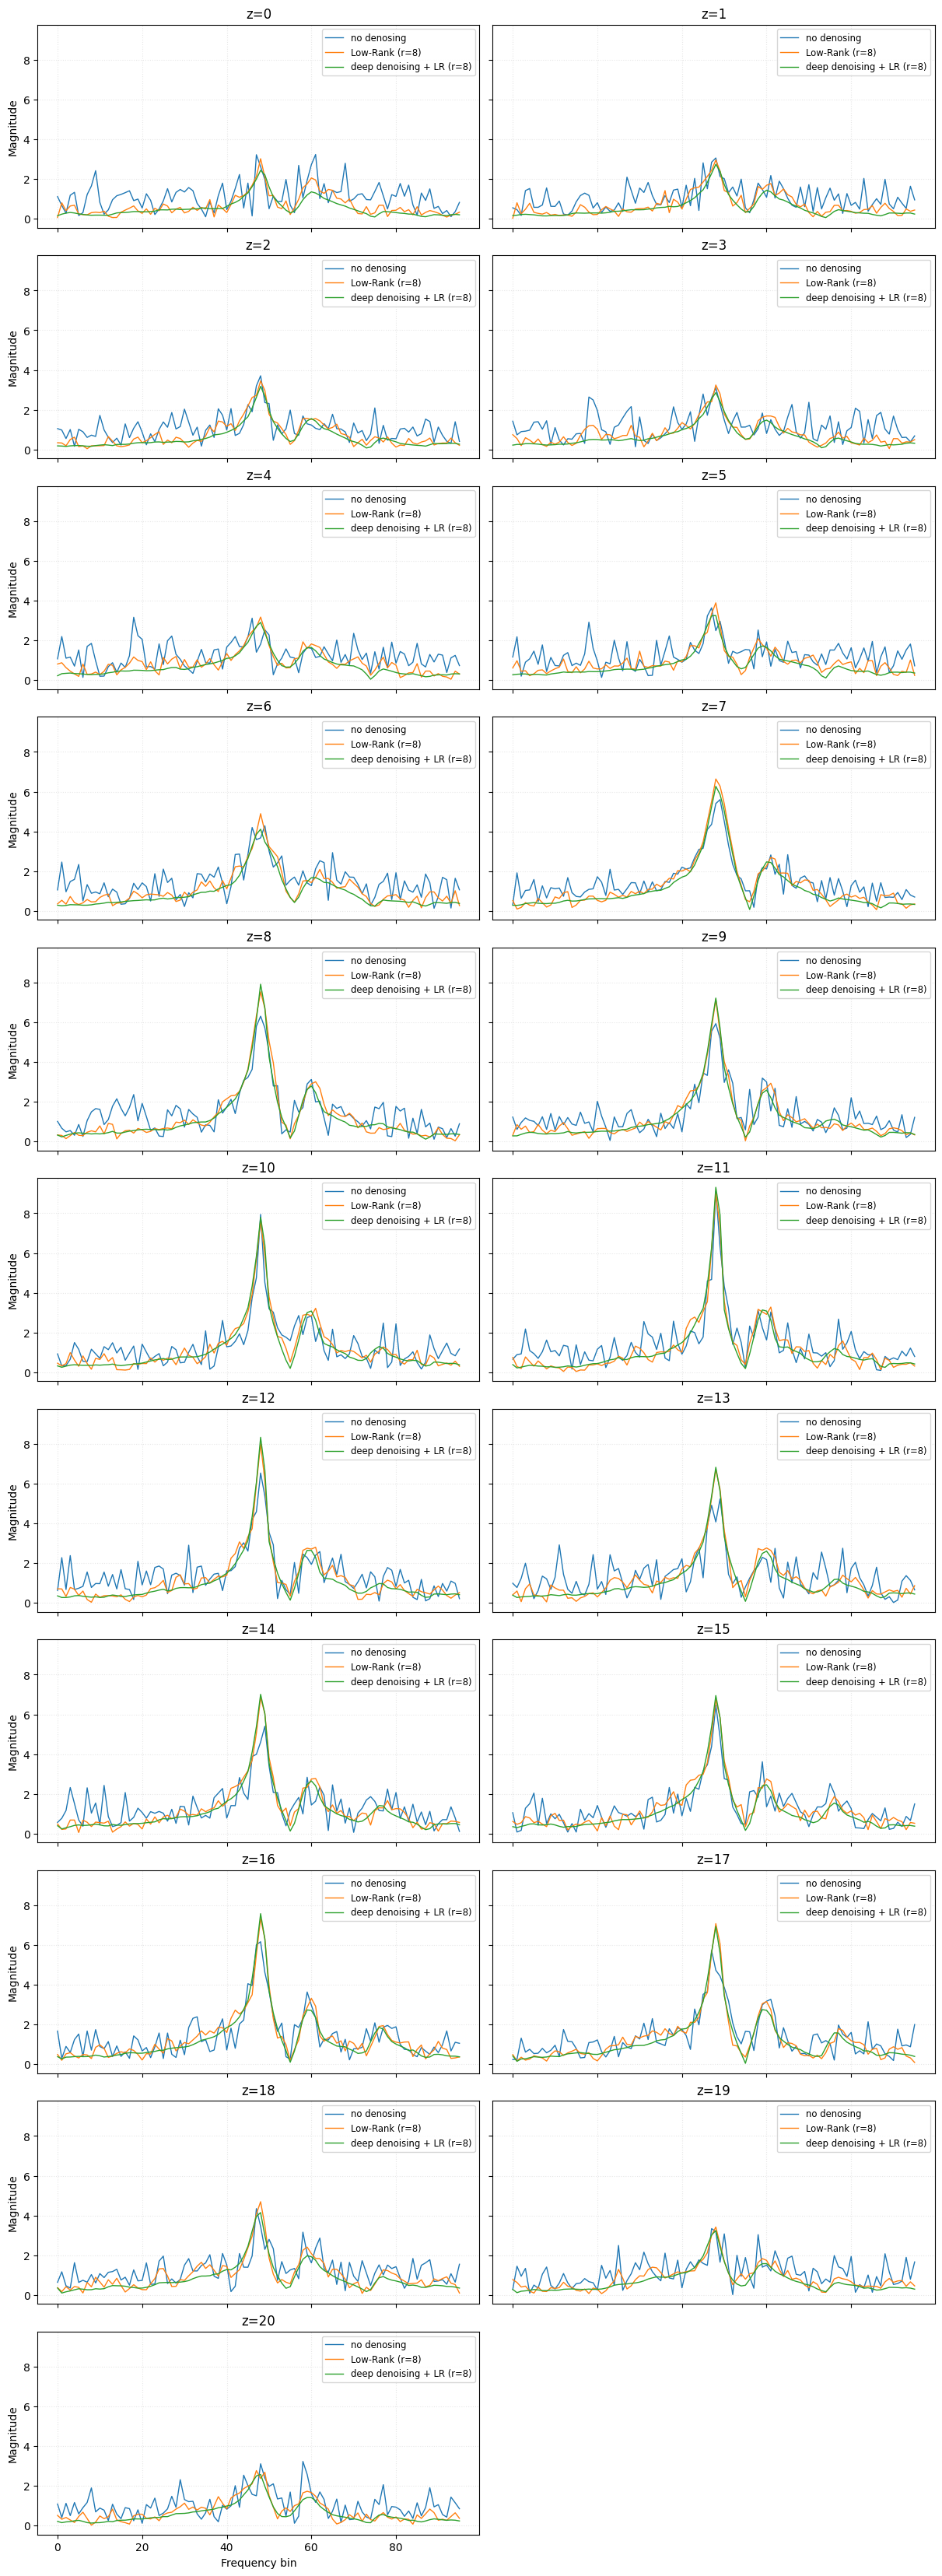

In [9]:
x,y,T = 10, 10, 0

# 2a) Deep-Denoising Spektrum
spec_deep = np.fft.fft(out_data, axis=3)
spec_deep = np.fft.fftshift(spec_deep, axes=3)

# 2b) Noisy Input Spektrum
spec_noisy = np.fft.fft(tgt_data, axis=3)
spec_noisy = np.fft.fftshift(spec_noisy, axes=3)

# 2c) Low-Rank Baseline Spektrum
spec_lr = np.fft.fft(baseline_data, axis=3)
spec_lr = np.fft.fftshift(spec_lr, axes=3)

# ── 21 Spektren für z=0…20 in einem 5×5-Grid plotten ─────────────────────────

# ── 21 Spektren (Noisy vs. Low-Rank vs. Noise2Void) in 2 Spalten ────────────

# ── 21 Spektren in 2 Spalten mit eigener Legende pro Plot und größerer Figure ──

import numpy as np
import matplotlib.pyplot as plt

# Parameter
x, y, T = 10, 10, 7
Z       = spec_noisy.shape[2]   # Anzahl der z-Slices (hier 21)
F       = spec_noisy.shape[3]   # Anzahl der Frequenz-Bins
freqs   = np.arange(F)
rank    = 8                     # Rang für Low-Rank

# Grid-Layout: 2 Spalten, genug Zeilen
n_cols  = 2
n_rows  = int(np.ceil(Z / n_cols))

# Figure größer machen: Breite × Höhe in Zoll
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(12, n_rows * 3),
    sharex=True, sharey=True,
    constrained_layout=True
)

for z in range(Z):
    i, j = divmod(z, n_cols)
    ax = axes[i, j]

    # Magnituden extrahieren
    mag_noisy = np.abs(spec_noisy[x, y, z, :, T])
    mag_lr    = np.abs(spec_lr   [x, y, z, :, T])
    mag_deep  = np.abs(spec_deep [x, y, z, :, T])

    # Plots
    ax.plot(freqs, mag_noisy, '-',  label='no denosing', linewidth=1)
    ax.plot(freqs, mag_lr,    '-', label=f'Low-Rank (r={rank})', linewidth=1)
    ax.plot(freqs, mag_deep,  '-',  label=f'deep denoising + LR (r={rank})', linewidth=1)

    ax.set_title(f"z={z}")
    ax.grid(True, linestyle=':', alpha=0.3)

    # Legende für jeden Subplot
    ax.legend(fontsize='small', loc='upper right')

    # Achsenbeschriftungen nur außen
    if i == n_rows - 1:
        ax.set_xlabel("Frequency bin")
    if j == 0:
        ax.set_ylabel("Magnitude")

# Leere Subplots ausblenden
for idx in range(Z, n_rows * n_cols):
    i, j = divmod(idx, n_cols)
    axes[i, j].axis('off')

plt.savefig("spectra.png", dpi=300)
plt.show()



# Compare spectral peaks

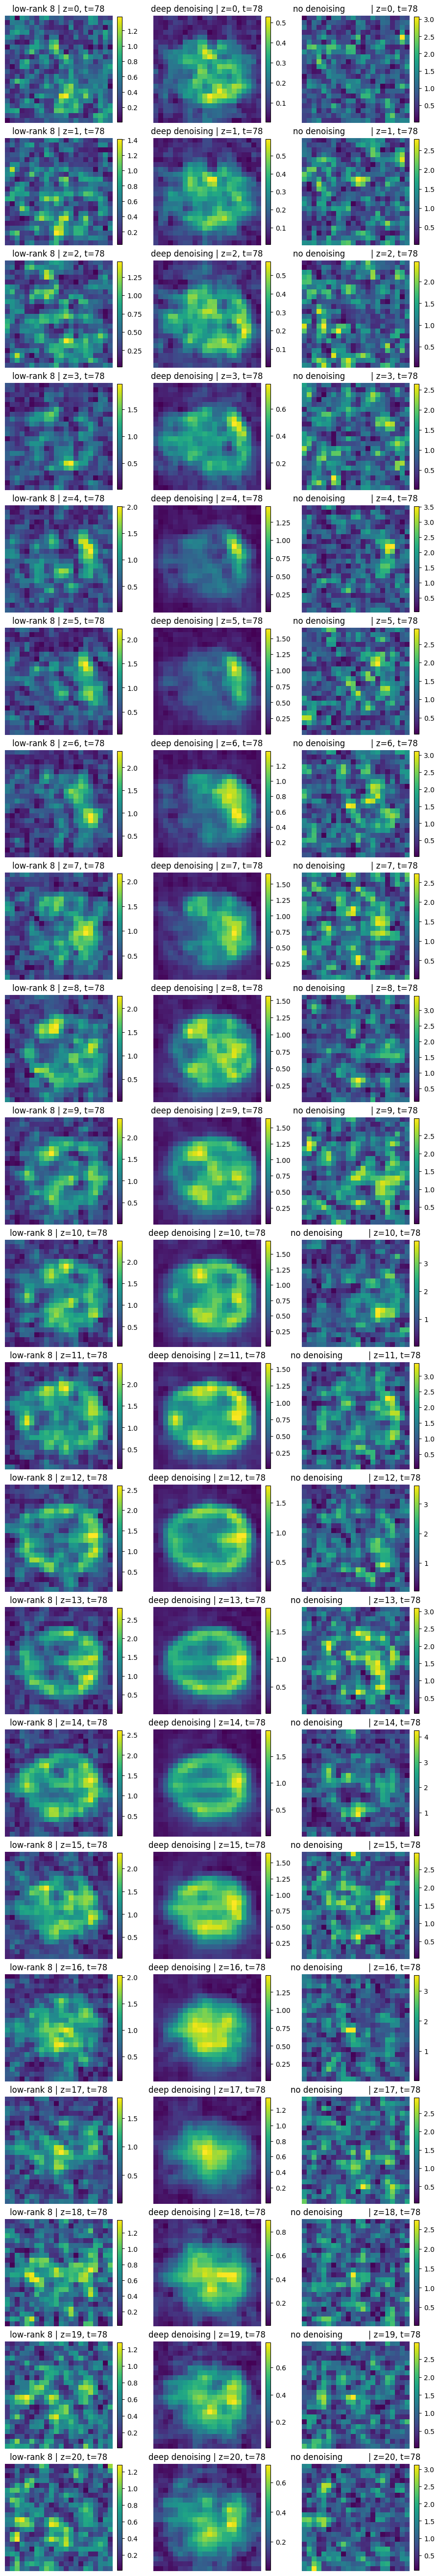

In [10]:
# ── Vergleich aller Z-Slices: Low-Rank | Deep Denoising | Input ─────────────

import numpy as np
import matplotlib.pyplot as plt

# 1) t- und T-Indizes einstellen
t, T = 78, 7

# 2) Anzahl der Z-Slices automatisch ermitteln
n_slices = out_data.shape[2]

# 3) Subplots erzeugen: n_slices Zeilen × 3 Spalten
fig, axes = plt.subplots(
    n_slices, 3,
    figsize=(9, n_slices * 2.5),
    constrained_layout=True
)

for i, z in enumerate(range(n_slices)):
    # 4) 2D-Slices extrahieren
    slice_lr   = np.abs(baseline_data_ft[:, :, z, t, T])  # Low-Rank
    slice_deep = np.abs(out_data_ft[:, :, z, t, T])       # Deep Denoised
    slice_in   = np.abs(tgt_data_ft[:, :, z, t, T])       # Original Input

    # 5a) Low-Rank
    im0 = axes[i, 0].imshow(slice_lr,   cmap='viridis')
    axes[i, 0].set_title(f"low-rank {rank} | z={z}, t={t}")
    axes[i, 0].axis('off')
    plt.colorbar(im0, ax=axes[i, 0], fraction=0.046, pad=0.04)

    # 5b) Deep Denoising
    im1 = axes[i, 1].imshow(slice_deep, cmap='viridis')
    axes[i, 1].set_title(f"deep denoising | z={z}, t={t}")
    axes[i, 1].axis('off')
    plt.colorbar(im1, ax=axes[i, 1], fraction=0.046, pad=0.04)

    # 5c) Input
    im2 = axes[i, 2].imshow(slice_in,   cmap='viridis')
    axes[i, 2].set_title(f"no denoising          | z={z}, t={t}")
    axes[i, 2].axis('off')
    plt.colorbar(im2, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.savefig("denoising_p2n.png", dpi=300)
plt.show()

# Compare average spectra
Here I compare the average spectrum over time (which is a high SNR estimate) for gey matter which matter and all matter

In [12]:
avg_out = np.mean(out_data_ft, axis=(0, 1, 2))

avg_tgt = np.mean(tgt_data_ft, axis=(0, 1, 2))

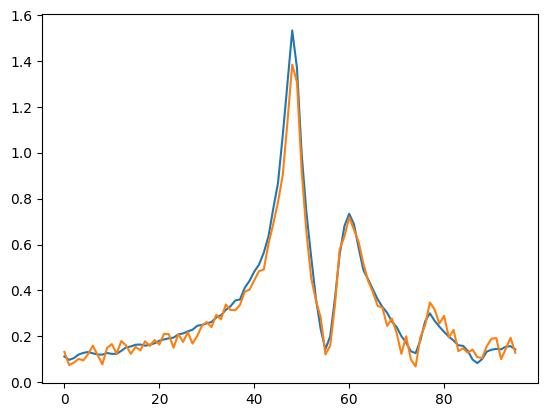

In [21]:
x,y,z, T = 10,10,10,7

Line = np.abs(avg_out)[:,T]
Line_2 = np.abs(avg_tgt)[:,T]

plt.plot(Line)
plt.plot(Line_2)